In [125]:
import matplotlib.pyplot as plt
import torch
from cryosim.pdb2mrc import PDB2MRC
from cryosim.plotting_tools import *
from cryosim.crowding import poisson_disk_neighbors
from cryosim.icemaker import Icemaker
from matplotlib.collections import PatchCollection
from cryosim.rotations import random_quaternion, quaternion_to_rotation_matrix, rotate_volume, build_affine_matrix
import numpy as np

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# fetch pdb file
# note: warnings are from biopython, can be ignored.
pdb_code = "6bdf"
pm = PDB2MRC(pdb_code)
pm.fetch_pdb(pdb_folder="../pdb-data/", assembly=1)

Assemblies available: 1
6bdf: Fetching Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.
Parsing ../pdb-data/6bdf-assembly1.cif.


Extracting atom coordinates and element: 46382it [00:00, 172435.37it/s]


In [3]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 1  # angstrom, pixel size.
pm.build_particle(n=n, dx=dx)
V = pm.particle.detach().clone()

Building element S: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  5.81it/s]


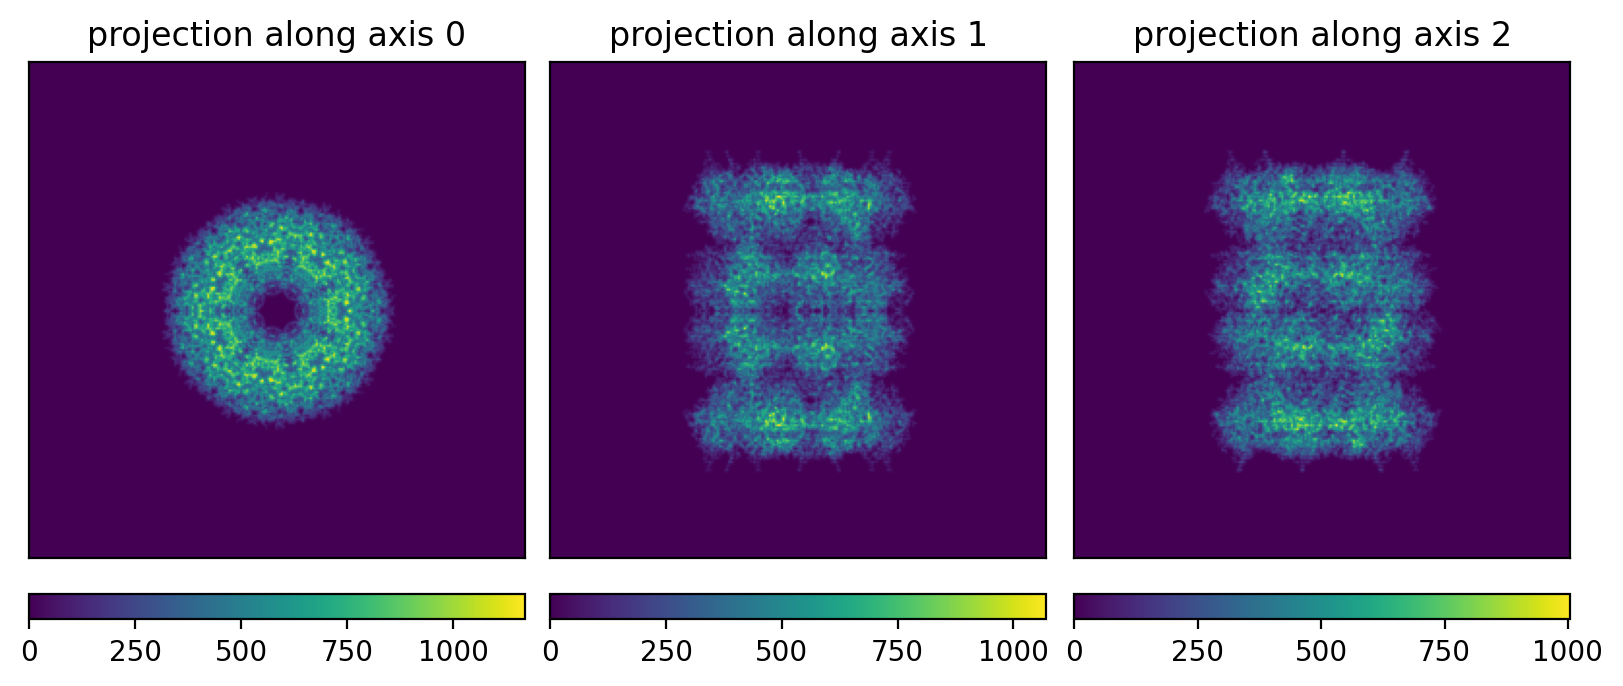

In [4]:
plot3d(V)

## Create micrograph

In [40]:
V.shape[1:]

torch.Size([256, 256])

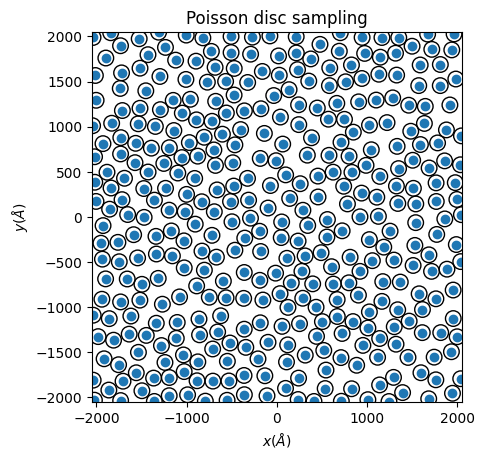

In [116]:
nxy = 4096
coords = poisson_disk_neighbors(pm.max_diameter * 0.9, box=(nxy,nxy), seed='random')

x = coords[:,0]
y = coords[:,1]

fig, axes = plt.subplots(1, 1, dpi=100)
ax = axes
_ = ax.scatter(-x, y)
circles = [plt.Circle((-xi, yi), radius=pm.max_diameter*0.9 / 2, fill=False) for xi, yi in zip(x,y)]
collection = PatchCollection(circles, match_original=True)
ax.add_collection(collection)
_ = ax.set(
    aspect="equal", xlabel=r"$x (\AA)$", ylabel=r"$y (\AA)$", xlim=[-dx*nxy/2, dx*nxy/2], ylim=[-dx*nxy/2, dx*nxy/2]
)
ax.set_title('Poisson disc sampling')

plt.show()

In [117]:
N = len(coords)
quaternions = random_quaternion(N)
rm = quaternion_to_rotation_matrix(quaternions)
am = build_affine_matrix(rm)
vols = rotate_volume(V, am)

In [118]:
vols.shape

torch.Size([380, 256, 256, 256])

In [119]:
def insert_volumes_centered_micrograph(
    micro_shape, volumes, positions, pixel_size=1.0, device='cpu'
):
    """
    Insert rotated 3D volumes into a micrograph centered at the origin.
    
    Parameters
    ----------
    micro_shape : tuple
        Shape of micrograph (Z, Y, X)
    volumes : torch.Tensor
        Rotated volumes, shape (N, Zp, Yp, Xp)
    positions : torch.Tensor
        (N,2) coordinates in physical units (y,x), origin at center
    pixel_size : float
        Physical size of one pixel (same units as positions)
    device : str
        'cuda' or 'cpu'
    
    Returns
    -------
    micrograph : torch.Tensor
        Micrograph with volumes inserted
    """
    Z, Y, X = micro_shape
    N, Zp, Yp, Xp = volumes.shape
    hy, hx = Yp // 2, Xp // 2

    # Preallocate micrograph
    micrograph = torch.zeros(micro_shape, device=device)
    volumes = volumes.to(device)
    positions = positions.to(device)

    # Convert positions from physical units to pixels
    positions_pixels = positions / pixel_size
    positions_int = positions_pixels.round().long()

    # Center of micrograph in array indices
    cy_center = Y // 2
    cx_center = X // 2

    for i in range(N):
        # Convert centered coordinates to array indices
        cy_index = cy_center + positions_int[i, 0]
        cx_index = cx_center + positions_int[i, 1]

        # Particle slice bounds
        y0 = cy_index - hy
        y1 = cy_index + hy
        x0 = cx_index - hx
        x1 = cx_index + hx

        # Clip slices to micrograph bounds
        y0_clip = max(y0, 0)
        y1_clip = min(y1, Y)
        x0_clip = max(x0, 0)
        x1_clip = min(x1, X)

        # Corresponding particle slice
        py0 = y0_clip - y0
        py1 = py0 + (y1_clip - y0_clip)
        px0 = x0_clip - x0
        px1 = px0 + (x1_clip - x0_clip)

        # Skip particle if fully outside
        if y1_clip <= y0_clip or x1_clip <= x0_clip:
            continue

        # Add volume to micrograph
        micrograph[:, y0_clip:y1_clip, x0_clip:x1_clip] += volumes[i, :, py0:py1, px0:px1]

    return micrograph


In [127]:
nz = 256
micro = insert_volumes_centered_micrograph((nz, nxy, nxy), vols, coords, pixel_size=dx)

In [121]:
micro.shape

torch.Size([256, 4096, 4096])

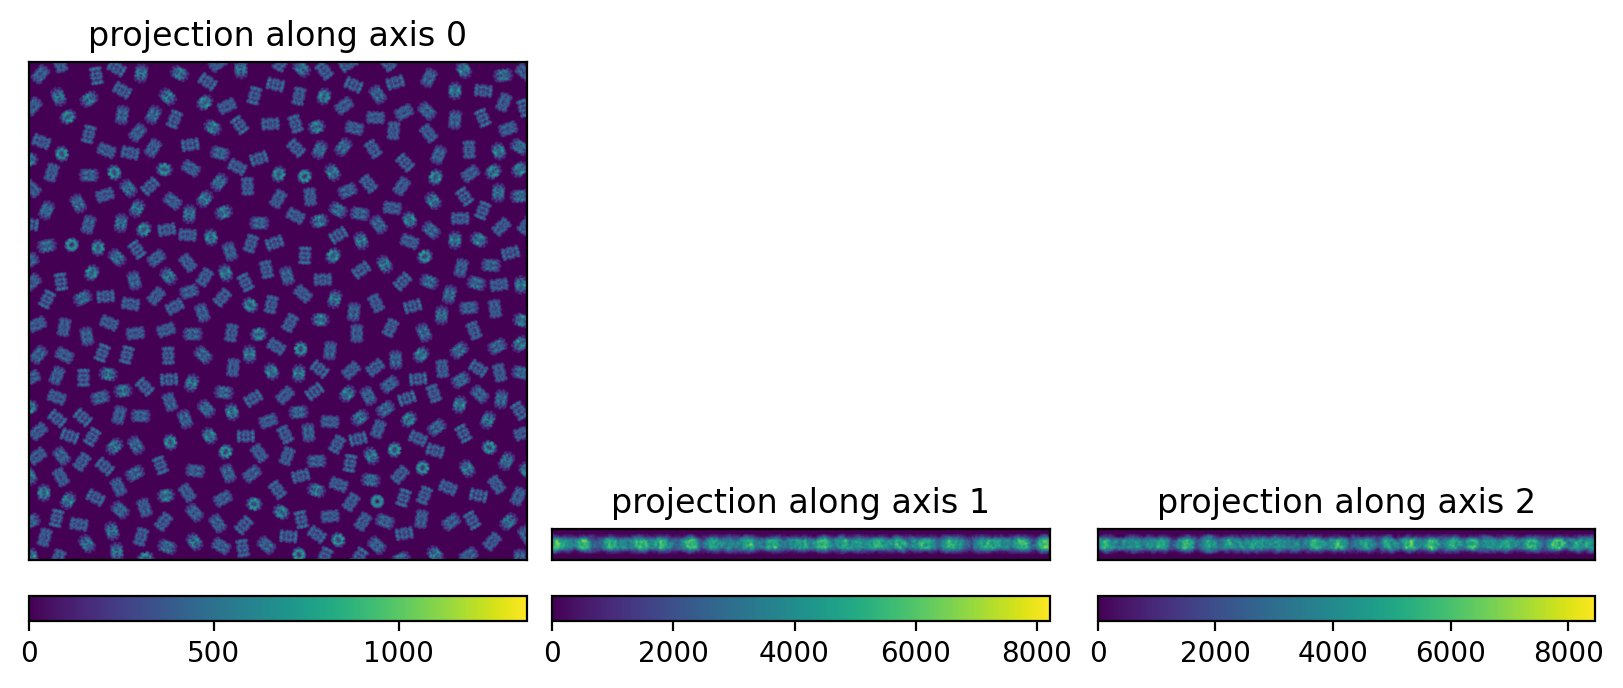

In [122]:
plot3d(micro)

In [128]:
im = Icemaker(n=nxy, dx=dx, nz=nz, verbose=False)

In [ ]:
ice = im.generate_ice(batchsize=1)

In [131]:
ice.shape

torch.Size([1, 256, 4096, 4096])

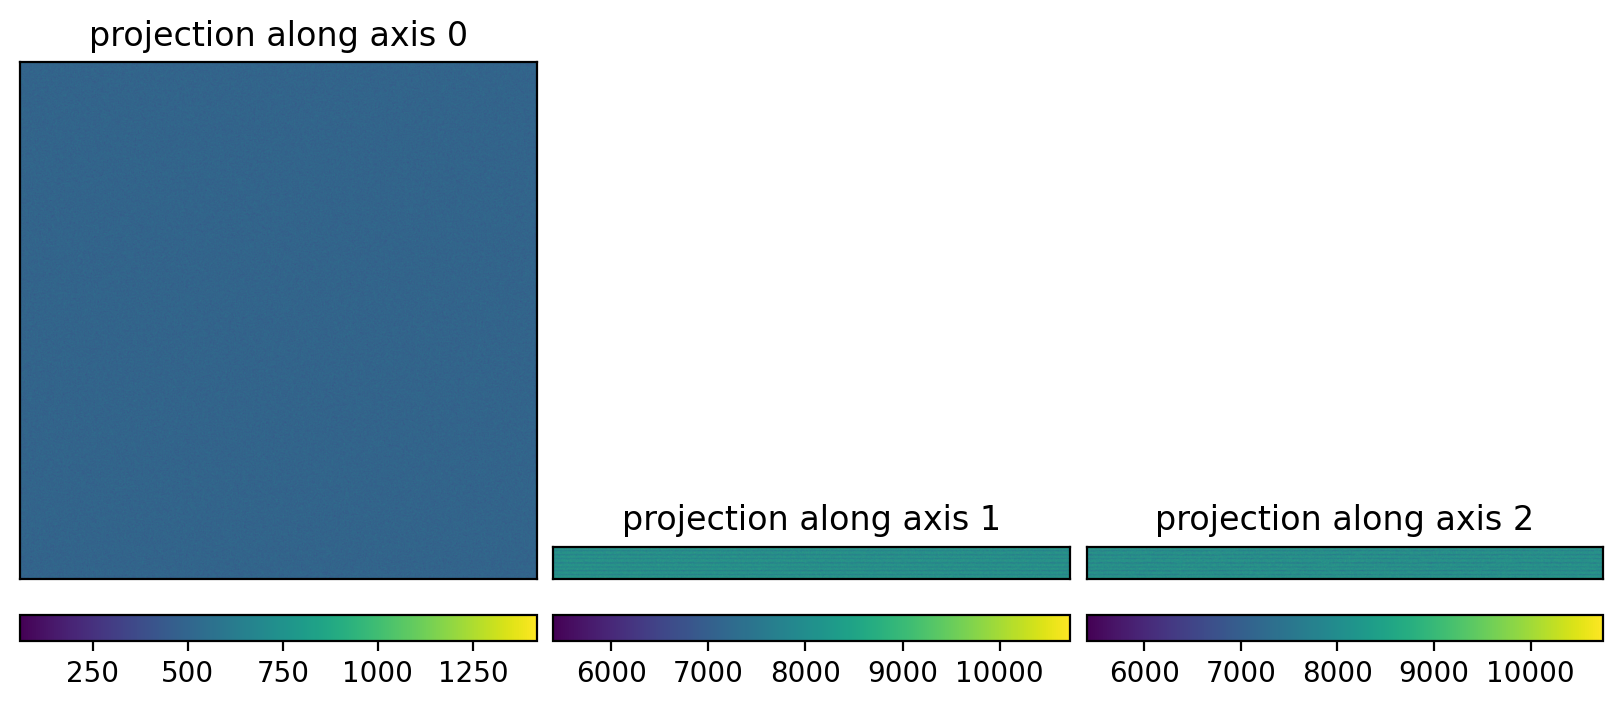

In [133]:
plot3d(ice.squeeze(0))

In [145]:
icemask = torch.ones_like(micro)
icemask[micro>10] = 0

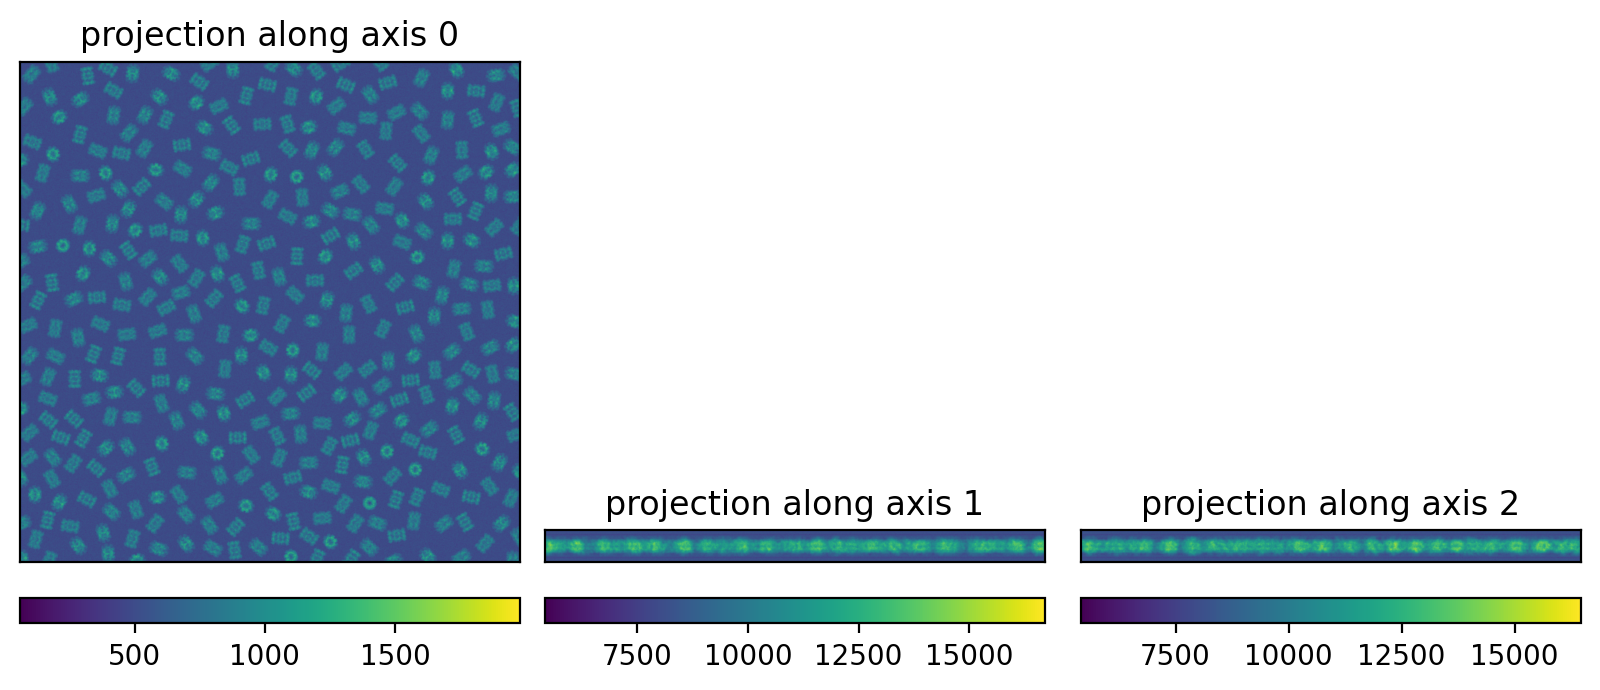

In [146]:
plot3d(ice[0] * icemask + micro)